**Aprendizaje Automático**

*Nombre:* Verónica Nathaly Alvarado Reyes

*Curso:* CDDEIA-ELNO-4-2

---
# Comparación de LDA y QDA con el Wine Dataset

## Análisis Discriminante Lineal y Cuadrático

En este cuaderno se comparan los modelos `LinearDiscriminantAnalysis` y `QuadraticDiscriminantAnalysis` utilizando el archivo original **`wine.data`** del repositorio UCI Machine Learning Repository.

El conjunto se utiliza **sin tratamiento previo**. Esto significa que no se eliminan columnas, no se imputan datos, no se normaliza y no se estandariza. La única preparación realizada es separar los datos en entrenamiento y prueba.

## 1. Importación de librerías

Se utilizan librerías para manejar los datos, crear gráficos, dividir el conjunto, entrenar los modelos y calcular las métricas de evaluación.

In [1]:
# Librerías para trabajar con los datos
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Herramientas de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Configuración general para observar mejor las tablas y figuras
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 10

# Paleta de colores utilizada
COLOR_AZUL = "#355C7D"
COLOR_MORADO = "#6C5B7B"
COLOR_ROSA = "#C06C84"
COLOR_DORADO = "#F8B195"
COLOR_VERDE = "#4E937A"

PALETA_CLASES = [COLOR_AZUL, COLOR_MORADO, COLOR_ROSA]

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga del archivo original `wine.data`

El archivo original no incluye encabezados. Por esta razón, los nombres de las 14 columnas se agregan manualmente. La primera columna corresponde a la variable objetivo y las otras 13 son variables predictoras.

In [2]:
# Nombres oficiales de las columnas del Wine Dataset
columnas = [
    "class",
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280_od315_of_diluted_wines",
    "proline"
]

# Se busca primero el archivo subido
rutas_posibles = [
    Path("wine.data"),
    Path("/content/wine.data"),
    Path("/mnt/data/wine.data")
]

ruta_local = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_local is not None:
    df = pd.read_csv(ruta_local, header=None, names=columnas)
    print(f"Archivo cargado desde: {ruta_local}")
else:
    # Este enlace se usa únicamente como respaldo cuando el archivo no está disponible.
    url_uci = (
        "https://archive.ics.uci.edu/ml/"
        "machine-learning-databases/wine/wine.data"
    )
    df = pd.read_csv(url_uci, header=None, names=columnas)
    print("Archivo cargado desde el repositorio oficial UCI.")

df.head()

Archivo cargado desde: wine.data


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 3. Descripción del conjunto de datos

El Wine Dataset contiene resultados de análisis químicos aplicados a vinos procedentes de tres cultivares de una misma región de Italia.

Sus características principales son:

- **178 observaciones**;
- **13 variables predictoras numéricas**;
- una variable objetivo llamada `class`;
- **3 clases**, codificadas como 1, 2 y 3;
- no presenta valores faltantes;
- cada fila representa una muestra de vino.

In [3]:
# Separación entre variables predictoras y variable objetivo
X = df.drop(columns="class")
y = df["class"]

print("Dimensiones del dataset completo:", df.shape)
print("Número de observaciones:", df.shape[0])
print("Número de variables predictoras:", X.shape[1])
print("Variable objetivo: class")
print("Cantidad de clases:", y.nunique())
print("Clases encontradas:", sorted(y.unique()))

Dimensiones del dataset completo: (178, 14)
Número de observaciones: 178
Número de variables predictoras: 13
Variable objetivo: class
Cantidad de clases: 3
Clases encontradas: [np.int64(1), np.int64(2), np.int64(3)]


## 4. Exploración de los datos

Se revisan las dimensiones, los tipos de variables, los valores faltantes, las estadísticas descriptivas y la distribución de las clases.

In [4]:
# Se revisa la estructura general del conjunto
print("DIMENSIONES")
print(df.shape)

# Se comprueba el tipo de cada variable
print("\nTIPOS DE VARIABLES")
print(df.dtypes)

# Se verifica si existen valores faltantes
print("\nVALORES FALTANTES POR VARIABLE")
print(df.isnull().sum())

print("\nTOTAL DE VALORES FALTANTES")
print(df.isnull().sum().sum())

DIMENSIONES
(178, 14)

TIPOS DE VARIABLES
class                             int64
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                         int64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280_od315_of_diluted_wines    float64
proline                           int64
dtype: object

VALORES FALTANTES POR VARIABLE
class                           0
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intens

In [5]:
# Las estadísticas descriptivas muestran media, desviación,
# valores mínimos, máximos y cuartiles
df.describe().T

,count,mean,std,min,25%,50%,75%,max
class,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [6]:
# Se calcula la frecuencia y el porcentaje de cada clase
distribucion_clases = pd.DataFrame({
    "frecuencia": y.value_counts().sort_index(),
    "porcentaje": y.value_counts(normalize=True).sort_index().mul(100).round(2)
})

distribucion_clases.index.name = "clase"
distribucion_clases

,frecuencia,porcentaje
clase,,
1,59,33.15
2,71,39.89
3,48,26.97


### Interpretación de la exploración

El conjunto contiene solamente variables numéricas y no presenta valores faltantes. También se observa que las escalas son diferentes. Por ejemplo, algunas variables tienen valores pequeños, mientras que `proline` supera ampliamente el valor de mil. En este no se modifican esas escalas porque la instrucción es utilizar Wine sin tratamiento. Las tres clases tienen cantidades diferentes de observaciones, pero no existe un desbalance extremo.

## 5. Visualización de los datos

Se presentan cuatro visualizaciones para comprender mejor la distribución y las relaciones existentes entre las variables.

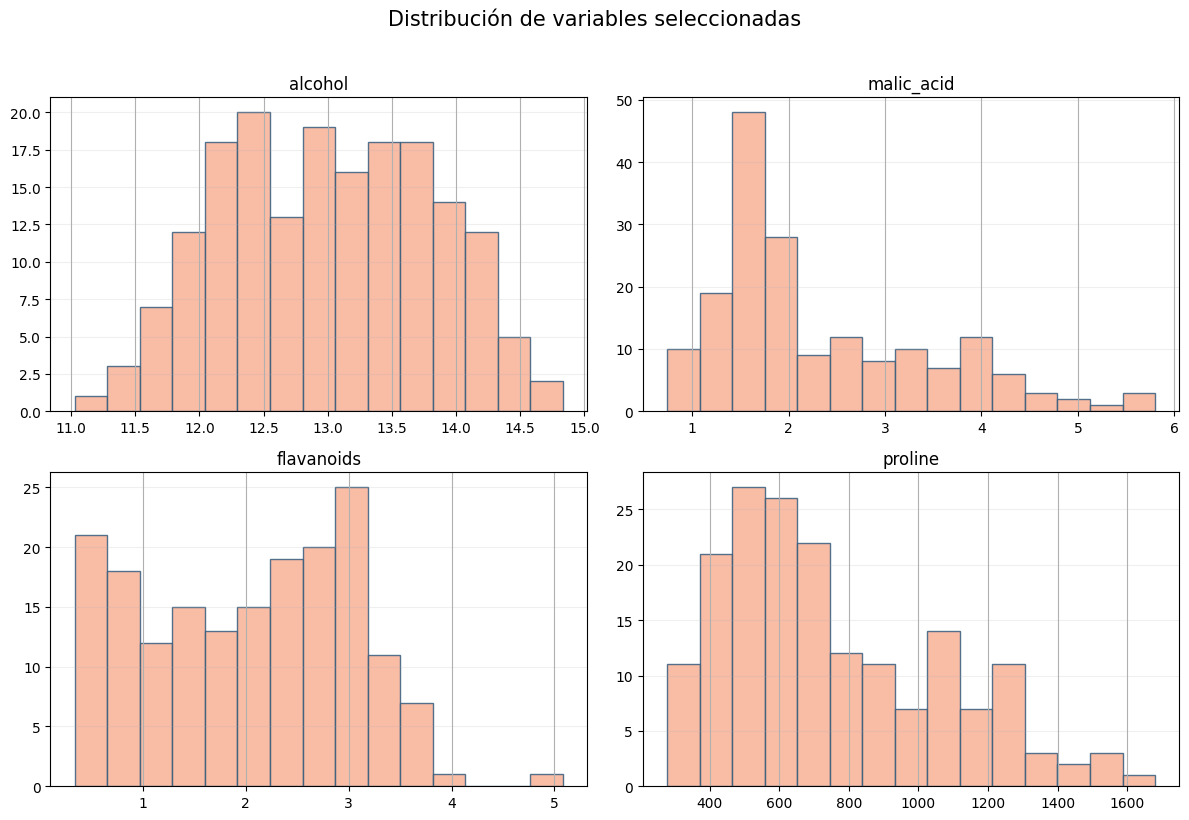

In [7]:
# VISUALIZACIÓN 1: histogramas
# Se seleccionan cuatro variables para observar su distribución
variables_histograma = ["alcohol", "malic_acid", "flavanoids", "proline"]

axes = df[variables_histograma].hist(
    bins=15,
    figsize=(12, 8),
    color=COLOR_DORADO,
    edgecolor=COLOR_AZUL,
    alpha=0.85
)

plt.suptitle("Distribución de variables seleccionadas", y=1.02, fontsize=15)

for fila in axes:
    for eje in fila:
        eje.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

**Interpretación:** las variables presentan distribuciones diferentes. `Alcohol` se concentra en un intervalo relativamente reducido, mientras que `proline` muestra una dispersión mucho mayor. Esto confirma que las variables se encuentran en escalas distintas, aunque sus valores originales se mantienen.

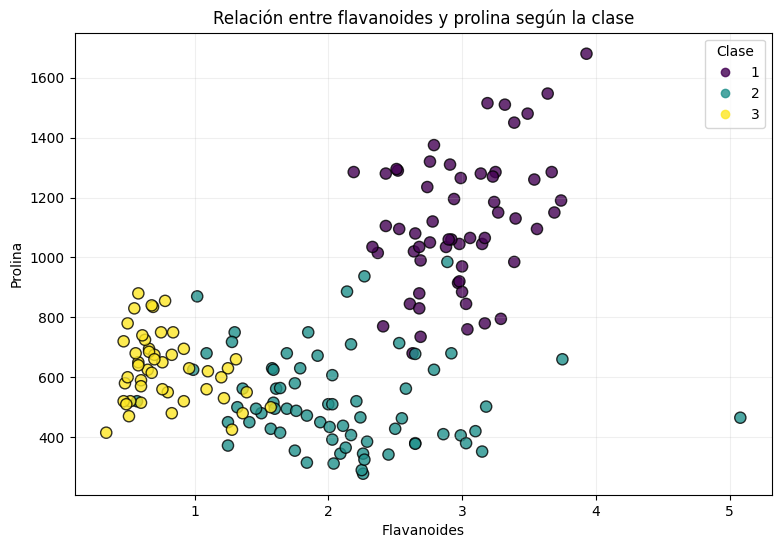

In [8]:
# VISUALIZACIÓN 2: diagrama de dispersión
# Se comparan flavanoides y prolina para observar la separación entre clases
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["flavanoids"],
    df["proline"],
    c=df["class"],
    cmap="viridis",
    alpha=0.80,
    edgecolors="black",
    s=65
)

plt.xlabel("Flavanoides")
plt.ylabel("Prolina")
plt.title("Relación entre flavanoides y prolina según la clase")
plt.legend(*scatter.legend_elements(), title="Clase")
plt.grid(alpha=0.20)
plt.show()

**Interpretación:** las tres clases tienden a ocupar zonas diferentes según los valores de flavanoides y prolina. Sin embargo, algunos puntos quedan próximos entre sí, por lo que no siempre es posible separar completamente las clases utilizando solamente estas dos variables.

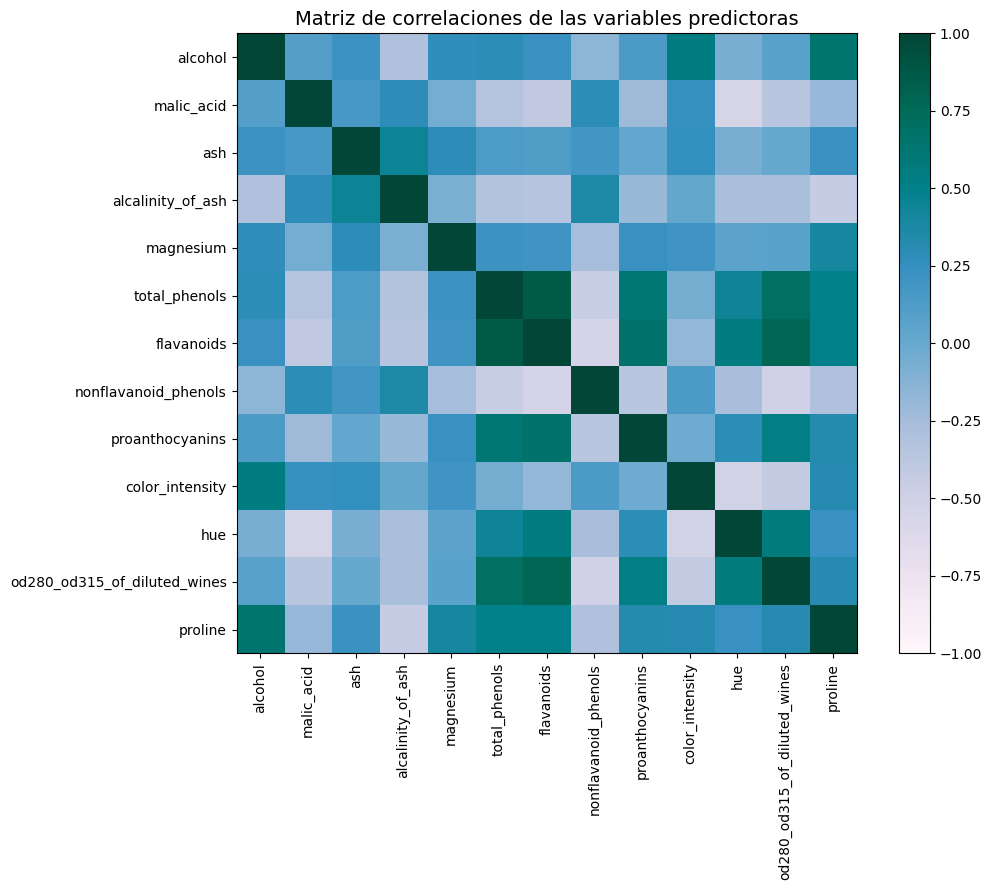

In [9]:
# VISUALIZACIÓN 3: mapa de correlaciones
# La matriz permite identificar relaciones positivas o negativas.
correlaciones = X.corr()

fig, ax = plt.subplots(figsize=(12, 9))
imagen = ax.imshow(
    correlaciones,
    cmap="PuBuGn",
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(correlaciones.columns)))
ax.set_yticks(np.arange(len(correlaciones.columns)))
ax.set_xticklabels(correlaciones.columns, rotation=90)
ax.set_yticklabels(correlaciones.columns)
ax.set_title("Matriz de correlaciones de las variables predictoras", fontsize=14)

fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**Interpretación:** existen variables que se relacionan de manera positiva y otras de forma negativa. Varias características asociadas a los compuestos fenólicos presentan correlaciones importantes. Estas relaciones muestran que algunas propiedades químicas cambian conjuntamente.

/tmp/ipykernel_510/153690506.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  cajas = eje.boxplot(
/tmp/ipykernel_510/153690506.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  cajas = eje.boxplot(
/tmp/ipykernel_510/153690506.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  cajas = eje.boxplot(
/tmp/ipykernel_510/153690506.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  cajas = eje.boxplot(


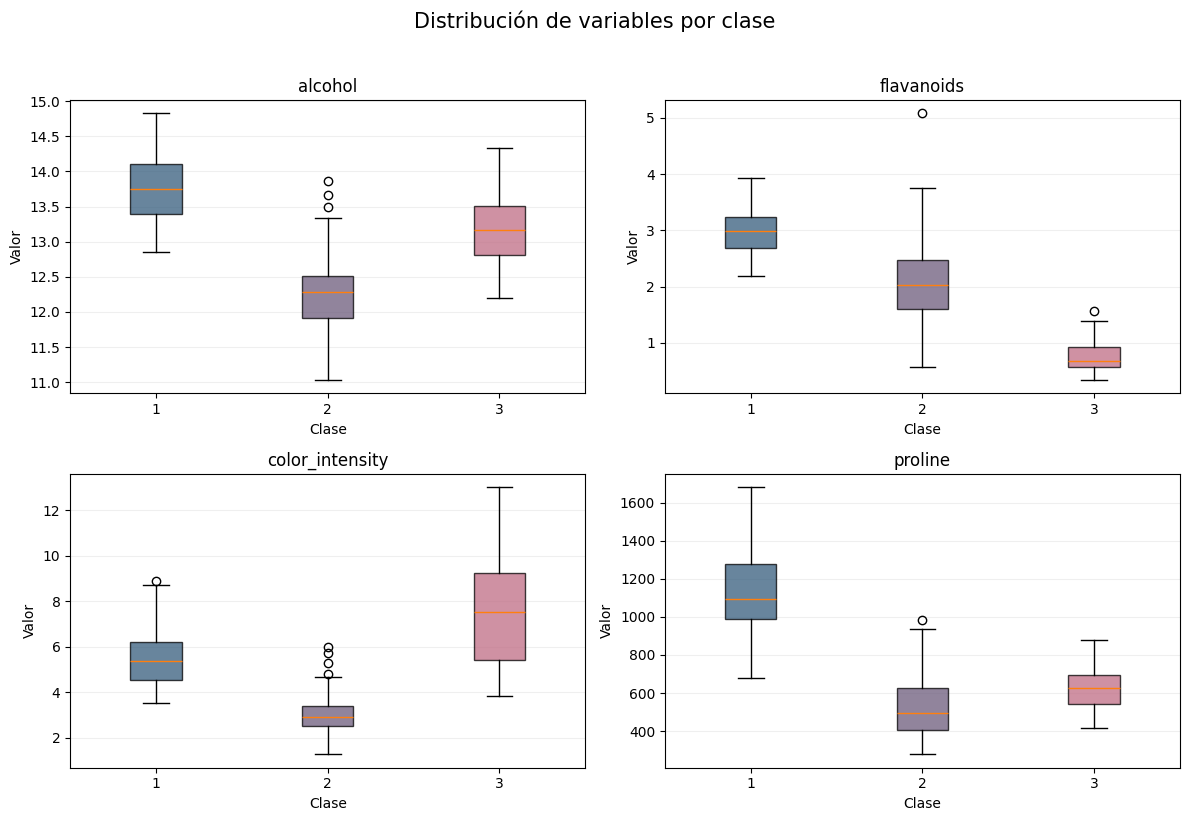

In [10]:
# VISUALIZACIÓN 4: boxplots
# Se comparan la mediana, dispersión y posibles valores atípicos por clase.
variables_boxplot = ["alcohol", "flavanoids", "color_intensity", "proline"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for eje, variable in zip(axes.ravel(), variables_boxplot):
    datos_por_clase = [
        df.loc[df["class"] == clase, variable]
        for clase in sorted(df["class"].unique())
    ]

    cajas = eje.boxplot(
        datos_por_clase,
        labels=["1", "2", "3"],
        patch_artist=True
    )

    for caja, color in zip(cajas["boxes"], PALETA_CLASES):
        caja.set_facecolor(color)
        caja.set_alpha(0.75)

    eje.set_title(variable)
    eje.set_xlabel("Clase")
    eje.set_ylabel("Valor")
    eje.grid(axis="y", alpha=0.20)

plt.suptitle("Distribución de variables por clase", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

**Interpretación:** las medianas y la dispersión cambian entre las clases. Esto indica que las propiedades químicas no se comportan de la misma manera en los tres grupos de vino. Las diferencias ayudan a comprender por qué LDA y QDA pueden utilizar estas variables para clasificar las observaciones.

## 6. Preparación de los datos

Se divide el conjunto en **80 % para entrenamiento** y **20 % para prueba**. Se utiliza `stratify=y` para conservar aproximadamente la proporción original de las clases.



In [11]:
# División estratificada y reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts().sort_index())

print("\nDistribución en prueba:")
print(y_test.value_counts().sort_index())

Entrenamiento: (142, 13)
Prueba: (36, 13)

Distribución en entrenamiento:
class
1    47
2    57
3    38
Name: count, dtype: int64

Distribución en prueba:
class
1    12
2    14
3    10
Name: count, dtype: int64


## 7. Implementación de LDA

Se utiliza `LinearDiscriminantAnalysis()` con sus parámetros predeterminados. El modelo supone que las tres clases comparten una misma matriz de covarianza.

In [12]:
# Se crea y entrena el modelo LDA.
modelo_lda = LinearDiscriminantAnalysis()

inicio_lda = time.perf_counter()
modelo_lda.fit(X_train, y_train)
tiempo_lda = time.perf_counter() - inicio_lda

# Se predicen las clases del conjunto de prueba.
y_pred_lda = modelo_lda.predict(X_test)

print("Predicciones LDA:")
print(y_pred_lda)
print(f"Tiempo de entrenamiento: {tiempo_lda:.6f} segundos")

Predicciones LDA:
[1 3 1 1 2 1 1 2 2 3 2 3 1 2 1 2 2 1 2 1 2 2 1 1 2 2 1 3 2 3 1 3 2 3 3 3]
Tiempo de entrenamiento: 0.024791 segundos


In [13]:
# Se calculan las métricas de LDA
# average='macro' da la misma importancia a las tres clases
accuracy_lda = accuracy_score(y_test, y_pred_lda)
precision_lda = precision_score(y_test, y_pred_lda, average="macro", zero_division=0)
recall_lda = recall_score(y_test, y_pred_lda, average="macro", zero_division=0)
f1_lda = f1_score(y_test, y_pred_lda, average="macro", zero_division=0)
cm_lda = confusion_matrix(y_test, y_pred_lda, labels=[1, 2, 3])

print(f"Accuracy LDA:  {accuracy_lda:.4f}")
print(f"Precisión LDA: {precision_lda:.4f}")
print(f"Recall LDA:    {recall_lda:.4f}")
print(f"F1-score LDA:  {f1_lda:.4f}")

print("\nReporte de clasificación LDA:")
print(classification_report(
    y_test,
    y_pred_lda,
    labels=[1, 2, 3],
    target_names=["Clase 1", "Clase 2", "Clase 3"],
    zero_division=0
))

Accuracy LDA:  0.9444
Precisión LDA: 0.9505
Recall LDA:    0.9429
F1-score LDA:  0.9453

Reporte de clasificación LDA:
              precision    recall  f1-score   support

     Clase 1       0.92      1.00      0.96        12
     Clase 2       0.93      0.93      0.93        14
     Clase 3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



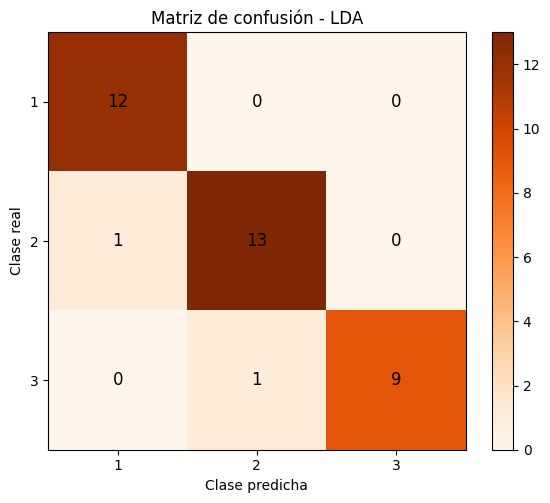

In [25]:
# Matriz de confusión de LDA
fig, ax = plt.subplots(figsize=(6, 5))
imagen = ax.imshow(cm_lda, cmap="Oranges")

ax.set_title("Matriz de confusión - LDA")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_xticks(range(3), labels=["1", "2", "3"])
ax.set_yticks(range(3), labels=["1", "2", "3"])

for i in range(cm_lda.shape[0]):
    for j in range(cm_lda.shape[1]):
        ax.text(j, i, cm_lda[i, j], ha="center", va="center", fontsize=12)

fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

### Interpretación de LDA

LDA clasifica correctamente la mayor parte de las observaciones del conjunto de prueba. Los pocos errores aparecen entre clases con características cercanas. En general, el resultado demuestra que una frontera lineal representa adecuadamente gran parte de la estructura del Wine Dataset.

## 8. Implementación de QDA

QDA estima una matriz de covarianza diferente para cada clase. Se mantiene `reg_param=0.0`, por lo que no se añade regularización.

In [15]:
# Se crea y entrena el modelo QDA
modelo_qda = QuadraticDiscriminantAnalysis(
    reg_param=0.0,
    tol=0.0001
)

inicio_qda = time.perf_counter()
modelo_qda.fit(X_train, y_train)
tiempo_qda = time.perf_counter() - inicio_qda

# Se realizan las predicciones
y_pred_qda = modelo_qda.predict(X_test)

print("Predicciones QDA:")
print(y_pred_qda)
print(f"Tiempo de entrenamiento: {tiempo_qda:.6f} segundos")

Predicciones QDA:
[1 3 1 2 2 1 1 2 2 3 2 3 1 3 1 2 2 1 2 1 2 2 1 1 2 2 1 3 2 3 1 3 2 3 3 3]
Tiempo de entrenamiento: 0.020316 segundos


In [16]:
# Se calculan las mismas métricas para QDA
accuracy_qda = accuracy_score(y_test, y_pred_qda)
precision_qda = precision_score(y_test, y_pred_qda, average="macro", zero_division=0)
recall_qda = recall_score(y_test, y_pred_qda, average="macro", zero_division=0)
f1_qda = f1_score(y_test, y_pred_qda, average="macro", zero_division=0)
cm_qda = confusion_matrix(y_test, y_pred_qda, labels=[1, 2, 3])

print(f"Accuracy QDA:  {accuracy_qda:.4f}")
print(f"Precisión QDA: {precision_qda:.4f}")
print(f"Recall QDA:    {recall_qda:.4f}")
print(f"F1-score QDA:  {f1_qda:.4f}")

print("\nReporte de clasificación QDA:")
print(classification_report(
    y_test,
    y_pred_qda,
    labels=[1, 2, 3],
    target_names=["Clase 1", "Clase 2", "Clase 3"],
    zero_division=0
))

Accuracy QDA:  1.0000
Precisión QDA: 1.0000
Recall QDA:    1.0000
F1-score QDA:  1.0000

Reporte de clasificación QDA:
              precision    recall  f1-score   support

     Clase 1       1.00      1.00      1.00        12
     Clase 2       1.00      1.00      1.00        14
     Clase 3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



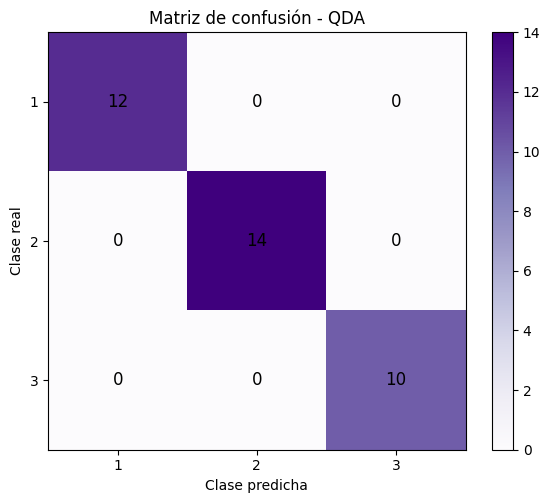

In [17]:
# Matriz de confusión de QDA
fig, ax = plt.subplots(figsize=(6, 5))
imagen = ax.imshow(cm_qda, cmap="Purples")

ax.set_title("Matriz de confusión - QDA")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_xticks(range(3), labels=["1", "2", "3"])
ax.set_yticks(range(3), labels=["1", "2", "3"])

for i in range(cm_qda.shape[0]):
    for j in range(cm_qda.shape[1]):
        ax.text(j, i, cm_qda[i, j], ha="center", va="center", fontsize=12)

fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

### Interpretación de QDA

QDA obtiene un resultado perfecto en la partición utilizada, porque clasifica correctamente las 36 observaciones de prueba. Esto indica que permitir una matriz de covarianza distinta por clase resulta útil en este caso. Sin embargo, este resultado no significa que QDA siempre alcance un 100 % con otras particiones o con datos nuevos.

## 9. Comparación de los modelos

Se comparan accuracy, precisión, recall, F1 y tiempo de entrenamiento.

In [18]:
# Tabla comparativa de resultados
comparacion = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [accuracy_lda, accuracy_qda],
    "Precisión macro": [precision_lda, precision_qda],
    "Recall macro": [recall_lda, recall_qda],
    "F1 macro": [f1_lda, f1_qda],
    "Tiempo de entrenamiento (s)": [tiempo_lda, tiempo_qda]
})

comparacion.set_index("Modelo").round(6)

,Accuracy,Precisión macro,Recall macro,F1 macro,Tiempo de entrenamiento (s)
Modelo,,,,,
LDA,0.944444,0.950549,0.942857,0.945313,0.024791
QDA,1.000000,1.000000,1.000000,1.000000,0.020316


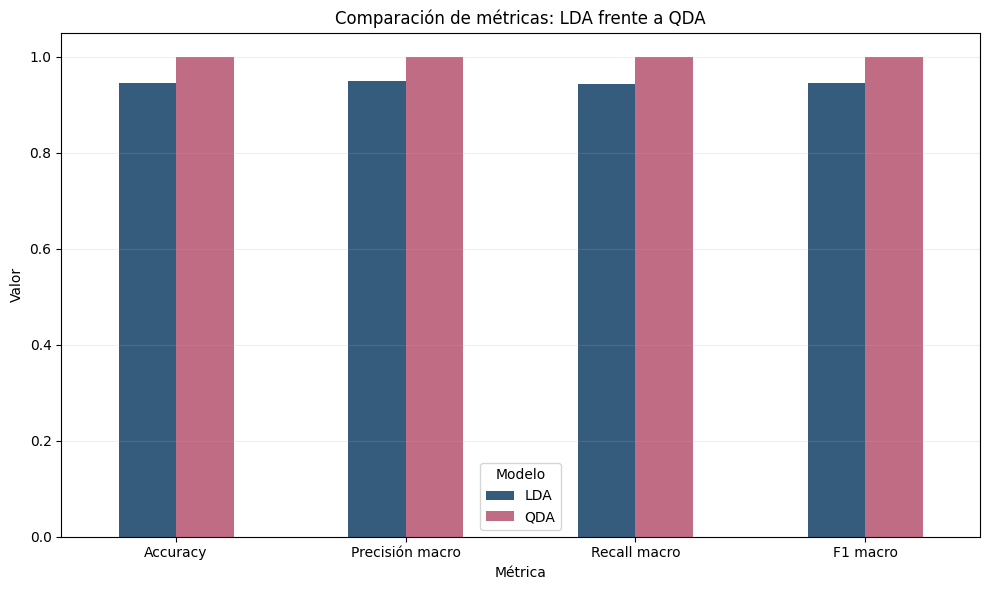

In [19]:
# Comparación gráfica de las métricas
metricas_grafico = comparacion.set_index("Modelo")[
    ["Accuracy", "Precisión macro", "Recall macro", "F1 macro"]
].T

metricas_grafico.plot(
    kind="bar",
    figsize=(10, 6),
    color=[COLOR_AZUL, COLOR_ROSA]
)

plt.ylim(0, 1.05)
plt.ylabel("Valor")
plt.xlabel("Métrica")
plt.title("Comparación de métricas: LDA frente a QDA")
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y", alpha=0.20)
plt.tight_layout()
plt.show()

### Análisis comparativo

- LDA obtiene un accuracy alto y comete pocos errores.
- QDA clasifica correctamente todas las observaciones del conjunto de prueba.
- La ventaja de QDA puede relacionarse con su capacidad para representar diferencias en la dispersión de cada clase.
- LDA utiliza una estructura más sencilla y estima menos parámetros.
- QDA es más flexible, pero puede sobreajustarse cuando existen pocos datos.
- Ambos modelos entrenan rápidamente porque Wine es un conjunto pequeño.

## 10. Fronteras de decisión

Para representar las fronteras en dos dimensiones se seleccionan `flavanoids` y `proline`. Los modelos principales siguen utilizando las 13 variables; estos modelos adicionales se entrenan únicamente para crear los gráficos.

In [20]:
# Selección de dos variables para la representación
variables_2d = ["flavanoids", "proline"]
X_2d = X[variables_2d]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

lda_2d = LinearDiscriminantAnalysis()
qda_2d = QuadraticDiscriminantAnalysis()

lda_2d.fit(X_train_2d, y_train_2d)
qda_2d.fit(X_train_2d, y_train_2d)

print("Accuracy LDA con dos variables:",
      round(accuracy_score(y_test_2d, lda_2d.predict(X_test_2d)), 4))
print("Accuracy QDA con dos variables:",
      round(accuracy_score(y_test_2d, qda_2d.predict(X_test_2d)), 4))

Accuracy LDA con dos variables: 0.9167
Accuracy QDA con dos variables: 0.9722


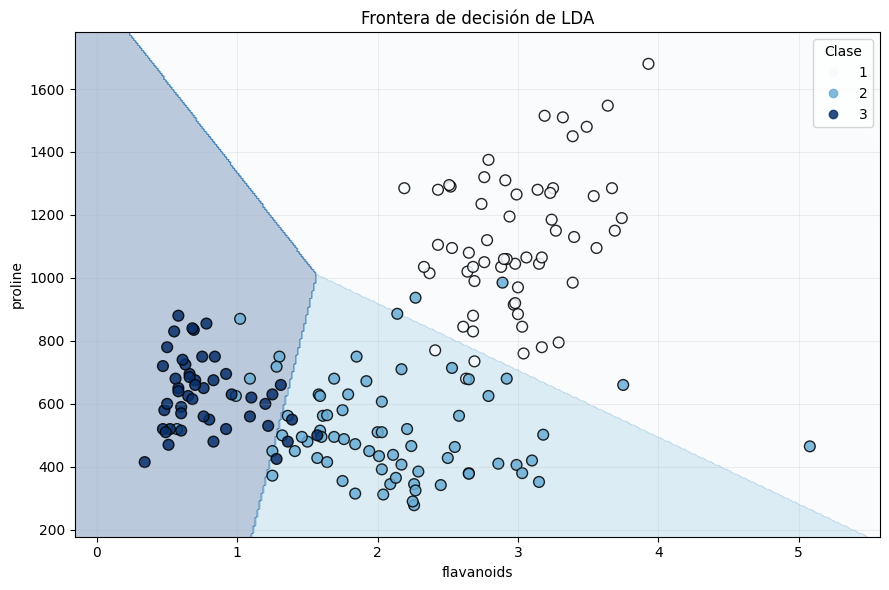

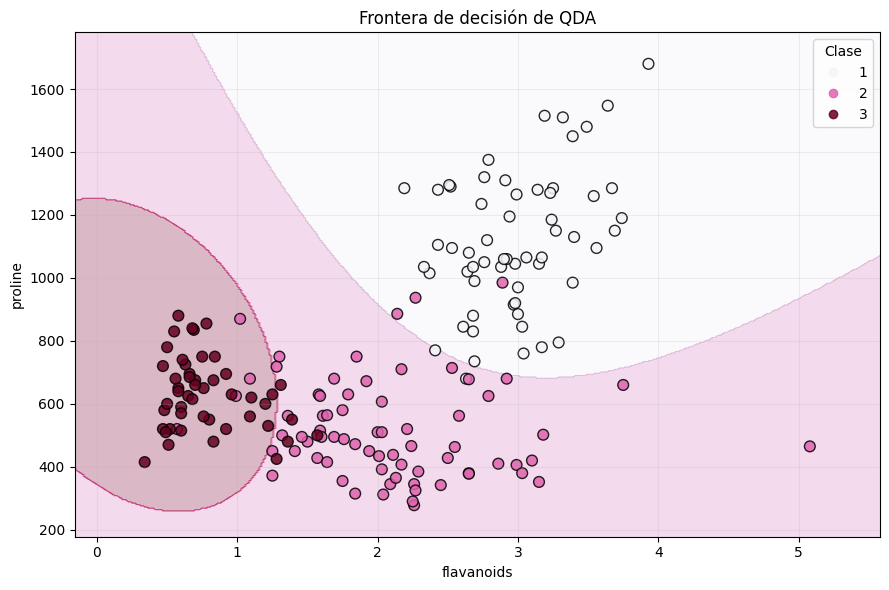

In [21]:
# Esta función crea una rejilla y consulta al modelo
# qué clase asignaría en cada zona del gráfico
def graficar_frontera(modelo, X_datos, y_datos, titulo, mapa_color):
    x_min = X_datos.iloc[:, 0].min() - 0.5
    x_max = X_datos.iloc[:, 0].max() + 0.5
    y_min = X_datos.iloc[:, 1].min() - 100
    y_max = X_datos.iloc[:, 1].max() + 100

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    rejilla = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=X_datos.columns
    )

    predicciones_rejilla = modelo.predict(rejilla).reshape(xx.shape)

    plt.figure(figsize=(9, 6))
    plt.contourf(
        xx,
        yy,
        predicciones_rejilla,
        alpha=0.28,
        cmap=mapa_color
    )

    puntos = plt.scatter(
        X_datos.iloc[:, 0],
        X_datos.iloc[:, 1],
        c=y_datos,
        cmap=mapa_color,
        edgecolors="black",
        alpha=0.85,
        s=60
    )

    plt.xlabel(X_datos.columns[0])
    plt.ylabel(X_datos.columns[1])
    plt.title(titulo)
    plt.legend(*puntos.legend_elements(), title="Clase")
    plt.grid(alpha=0.20)
    plt.tight_layout()
    plt.show()


graficar_frontera(
    lda_2d,
    X_2d,
    y,
    "Frontera de decisión de LDA",
    "Blues"
)

graficar_frontera(
    qda_2d,
    X_2d,
    y,
    "Frontera de decisión de QDA",
    "PuRd"
)

### Diferencias observadas

LDA genera separaciones principalmente rectas porque utiliza una matriz de covarianza compartida. QDA produce regiones curvas debido a que estima una matriz diferente para cada clase. Visualmente, QDA se adapta con mayor libertad a la forma de los grupos, aunque esa flexibilidad también aumenta el riesgo de sobreajuste.

## 11. Conclusiones

1. LDA presentó un desempeño alto utilizando los valores originales del Wine Dataset, por lo que una frontera lineal puede representar adecuadamente gran parte de la separación entre las clases.

2. QDA obtuvo el mejor resultado en esta partición, alcanzando valores máximos en accuracy, precisión, recall y F1.

3. Los supuestos estadísticos influyen en los resultados. LDA comparte una matriz de covarianza, mientras que QDA estima una matriz diferente para cada clase.

4. La mayor flexibilidad de QDA no significa que siempre sea superior. En conjuntos pequeños o con muchas variables puede sobreajustarse o presentar problemas al estimar las covarianzas.

5. Las fronteras de decisión coinciden con la teoría: LDA genera separaciones lineales y QDA genera separaciones curvas.

6. El archivo original `wine.data` puede utilizarse sin tratamiento previo, porque contiene variables numéricas, no presenta valores faltantes y posee tres clases claramente identificadas.

## 12. Resultados esperados

Con `random_state=42` y una división estratificada 80/20, los resultados esperados son:

| Modelo | Accuracy | Precisión macro | Recall macro | F1 macro |
|---|---:|---:|---:|---:|
| LDA | 0.9444 | 0.9505 | 0.9429 | 0.9453 |
| QDA | 1.0000 | 1.0000 | 1.0000 | 1.0000 |

Estos valores pueden variar si se cambia la semilla o la proporción de entrenamiento y prueba.